In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
import pandas as pd
import sys
import argparse
from collections import defaultdict
from _utils import *

In [ ]:
def compute_sensitivity(df, pred_col, model_name):
    
    df2 = df.dropna(subset=["true_subtype"]).copy()
    
    classes = sorted(df2["true_subtype"].unique())
    
    y_true = df2["true_subtype"]
    y_pred = df2[pred_col]
    
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    
    sensitivities = []
    
    for i, cls in enumerate(classes):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        
        sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
        sensitivities.append(sensitivity)
    
    return pd.DataFrame({
        "true_subtype": classes,
        "sensitivity": sensitivities,
        "model": model_name
    })

In [22]:
def compute_ppv(df, pred_col, model_name):
    
    df2 = df.dropna(subset=["true_subtype"]).copy()
    
    classes = sorted(df2["true_subtype"].unique())
    
    y_true = df2["true_subtype"]
    y_pred = df2[pred_col]
    
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    
    ppvs = []
    
    for i, cls in enumerate(classes):
        TP = cm[i, i]
        FP = cm[:, i].sum() - TP  # column sum minus TP
        
        ppv = TP / (TP + FP) if (TP + FP) > 0 else 0
        ppvs.append(ppv)
    
    return pd.DataFrame({
        "true_subtype": classes,
        #note: just calling it sensitivity so it works for the function below

        "sensitivity": ppvs,
        "model": model_name
    })

In [3]:
import pandas as pd
from sklearn.metrics import confusion_matrix

def compute_fp(df, pred_col, model_name):
    
    # Drop missing truth
    df2 = df.dropna(subset=["true_subtype"]).copy()
    
    # Ensure consistent class ordering
    classes = sorted(df2["true_subtype"].unique())
    
    y_true = df2["true_subtype"]
    y_pred = df2[pred_col]
    
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    
    # Compute FPR per class
    fp_rates = []
    
    for i, cls in enumerate(classes):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - (TP + FP + FN)
        
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
        fpr = 1 - specificity
        
        fp_rates.append(fpr)
    
    return pd.DataFrame({
        "true_subtype": classes,
        #note: just calling it sensitivity so it works for the function below
        "sensitivity": fp_rates,
        "model": model_name
    })

In [4]:
import pandas as pd
pred_df = pd.read_csv(PIPELINE_DATA_DIR / "predictions.csv")

In [5]:
pred_df

,file_hash,true_type,true_subtype,xgb_pred_type,xgb_pred_subtype,gpt_bl_pred_subtype,gpt_bl_pred_type,gpt_h_pred_subtype,gpt_h_pred_type,gpt_mini_pred_subtype,gpt_mini_pred_type,gpt_mini_h_pred_subtype,gpt_mini_h_pred_type
0,214ac5dc2f4310ad53036635fefe8f740eb2936d1d43ad...,I K,I K (Rare),I K,I K (Delayed Rectifier),I K (Rare),I K,I K (Rare),I K,I K (Rare),I K,I K (Rare),I K
1,bde4f05190ab1602ccc8a054fcd554f861af2a009d6cf7...,Neither,Z Neither,Neither,Z Neither,Z Neither,Neither,Z Neither,Neither,Z Neither,Neither,Z Neither,Neither
2,881a6233b3d2421b32006497530a61180e116ec6c9dfd5...,Receptor,R GABA,Receptor,R Glutamate (AMPA),R GABA,Receptor,R GABA,Receptor,R GABA,Receptor,R GABA,Receptor
3,d064875199b0206233fad90bbf5641d4eeacab0cdfbcea...,I K,I K (A-type),I K,I K (Rare),I K (A-type),I K,I K (A-type),I K,I K (A-type),I K,I K (A-type),I K
4,04fdb27c5f82a7ebeb4cc1f5ddd7d02d6f3f638e740c1e...,Receptor,R GABA,Receptor,R Glutamate (AMPA),R GABA,Receptor,R GABA,Receptor,R GABA,Receptor,R GABA,Receptor
...,...,...,...,...,...,...,...,...,...,...,...,...,...
248,6c8568b8e815e747ee65646ffad30dcb6c7434d0582f89...,I K,I K (A-type),I K,I K (A-type),I K (Rare),I K,I K (A-type),I K,I K (A-type),I K,I K (A-type),I K
249,36e4bf58cff67dccc387bfdcc699f9d858195530861eb8...,Neither,Z Neither,Neither,Z Neither,Z Neither,Neither,Z Neither,Neither,I Other (Rare),I Other,Z Neither,Neither
250,b1d2b7bb4889a16d4266f0d436dea7e6681834db56604c...,I K,I K (Ca-activated),I K,I K (Delayed Rectifier),I K (Delayed Rectifier),I K,I K (Delayed Rectifier),I K,I K (Delayed Rectifier),I K,I K (Delayed Rectifier),I K
251,40fd3e6f9b765906e599f8ff4ba77cc6c3955b5671997f...,I H,I H,I H,I H,I H,I H,I H,I H,I H,I H,I H,I H


In [6]:

sens_xgb   = compute_sensitivity(pred_df, "xgb_pred_subtype", "XGB")
sens_gpt   = compute_sensitivity(pred_df, "gpt_bl_pred_subtype", "GPT")
sens_gpt_h= compute_sensitivity(pred_df, "gpt_h_pred_subtype", "GPT_H")
sens_gpt52 = pd.concat([sens_xgb, sens_gpt, sens_gpt_h], ignore_index=True)


fp_xgb   = compute_fp(pred_df, "xgb_pred_subtype", "XGB")
fp_gpt   = compute_fp(pred_df, "gpt_bl_pred_subtype", "GPT")
fp_gpt_h= compute_fp(pred_df, "gpt_h_pred_subtype", "GPT_H")
fp_gpt52 = pd.concat([fp_xgb, fp_gpt, fp_gpt_h], ignore_index=True)

In [7]:

sens_xgb   = compute_sensitivity(pred_df, "xgb_pred_subtype", "XGB")
sens_gpt   = compute_sensitivity(pred_df, "gpt_mini_pred_subtype", "GPT")
sens_gpt_h= compute_sensitivity(pred_df, "gpt_mini_h_pred_subtype", "GPT_H")
sens_gptmini = pd.concat([sens_xgb, sens_gpt, sens_gpt_h], ignore_index=True)

fp_xgb   = compute_fp(pred_df, "xgb_pred_subtype", "XGB")
fp_gpt   = compute_fp(pred_df, "gpt_mini_pred_subtype", "GPT")
fp_gpt_h= compute_fp(pred_df, "gpt_mini_h_pred_subtype", "GPT_H")
fp_gptmini = pd.concat([fp_xgb, fp_gpt, fp_gpt_h], ignore_index=True)

In [24]:
ppv_xgb   = compute_ppv(pred_df, "xgb_pred_subtype", "XGB")
ppv_gpt   = compute_ppv(pred_df, "gpt_bl_pred_subtype", "GPT")
ppv_gpt_h= compute_ppv(pred_df, "gpt_h_pred_subtype", "GPT_H")
ppv_gpt52 = pd.concat([ppv_xgb, ppv_gpt, ppv_gpt_h], ignore_index=True)


ppv_xgb   = compute_ppv(pred_df, "xgb_pred_subtype", "XGB")
ppv_gpt   = compute_ppv(pred_df, "gpt_mini_pred_subtype", "GPT")
ppv_gpt_h= compute_ppv(pred_df, "gpt_mini_h_pred_subtype", "GPT_H")
ppv_gptmini = pd.concat([ppv_xgb, ppv_gpt, ppv_gpt_h], ignore_index=True)


In [26]:
ppv_gpt52.to_csv("gpt_ppv.csv", index=False)
ppv_gptmini.to_csv("gpt_mini_ppv.csv", index=False)

In [ ]:
sens_gpt52.to_csv("gpt_sensitivity.csv", index=False)
sens_gptmini.to_csv("gpt_mini_sensitivity.csv", index=False)

fp_gpt52.to_csv("gpt_fp.csv", index=False)
fp_gptmini.to_csv("gpt_mini_fp.csv", index=False)



In [27]:
sens_fp ="gpt_sensitivity.csv"
sens_mini_fp = "gpt_mini_sensitivity.csv"
fp_fp ="gpt_fp.csv"
fp_mini_fp = "gpt_mini_fp.csv"
ppv_fp = "gpt_ppv.csv"
ppv_mini_fp = "gpt_mini_ppv.csv"

In [17]:
#sens_fp = PIPELINE_DATA_DIR / "gpt_sensitivity.csv"

#E69F00
#00b3a4
##f94144

# Model to color mapping
MODEL_COLOR_MAP = {
    'XGB': 'black',
    'GPT': 'blue',
    'GPT_H': 'red'
}


def load_data_from_file(filename='gpt_sensitivity.xlsx'):
    """
    Load data from Excel or CSV file.
    
    Args:
        filename: Path to the data file
        
    Returns:
        pandas DataFrame with the loaded data
    """
    try:
        # Try loading as Excel first
        df = pd.read_excel(filename)
        print(f"Successfully loaded data from Excel file: {filename}")
    except Exception as e:
        print(f"Failed to load as Excel ({e}), trying CSV...")
        try:
            df = pd.read_csv(filename)
            print(f"Successfully loaded data from CSV file: {filename}")
        except Exception as e2:
            raise ValueError(f"Failed to load file as both Excel and CSV: {e2}")
    
    return df


def transform_tidy_data_to_plot_config(df, title="Sensitivity Plot", 
                                       xlabel="True Positive (%)",
                                       xticks=None, xticklabels=None):
    """
    Transform TIDY format data into my_plot structure.
    
    Args:
        df: DataFrame with columns 'true_subtype', 'sensitivity', 'model'
        title: Plot title
        xlabel: X-axis label
        xticks: X-axis tick positions
        xticklabels: X-axis tick labels
        
    Returns:
        Dictionary in my_plot format
    """
    # Group by true_subtype and model, aggregating sensitivity values
    # For each true_subtype, we want one entry with orange, blue, purple fields
    
    plot_data = []
    
    # Get unique subtypes
    subtypes = df['true_subtype'].unique()
    
    for subtype in subtypes:
        subtype_df = df[df['true_subtype'] == subtype]
        
        # Initialize the data entry for this subtype
        data_entry = {"name": subtype}
        
        # For each model, get the sensitivity value
        for model, color in MODEL_COLOR_MAP.items():
            model_data = subtype_df[subtype_df['model'] == model]
            
            if len(model_data) > 0:
                # If there are multiple entries, take the mean
                sensitivity = model_data['sensitivity'].mean()
                data_entry[color] = sensitivity
            else:
                # If no data for this model, set to 0 or skip
                data_entry[color] = 0
        
        plot_data.append(data_entry)
    
    # Create the plot configuration
    if xticks is None:
        xticks = [0, 0.25, 0.50, 0.75, 1]
    if xticklabels is None:
        xticklabels = ["0%", "25%", "50%", "75%", "100%"]
    
    plot_config = {
        "title": title,
        "xlabel": xlabel,
        "xticks": xticks,
        "xticklabels": xticklabels,
        "data": plot_data
    }
    
    return plot_config


def plot_custom_scatter(data, radius=0.05, title=None, xlabel=None, ylabel=None, 
                        xticks=None, xticklabels=None, yticks=None, yticklabels=None,
                        line_segments=None):
    """
    Plots points as mini-pie charts.
 
    Args:
        data: List of tuples (x, y, [colors])
        radius: The size of the pie chart markers
        title: Plot title
        xlabel: X-axis label
        ylabel: Y-axis label
        xticks: X-axis tick positions
        xticklabels: X-axis tick labels
        yticks: Y-axis tick positions
        yticklabels: Y-axis tick labels
        line_segments: List of tuples (y, x_min, x_max) for drawing horizontal line segments
    """
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Draw line segments first (so they're behind the pie charts)
    if line_segments:
        for y, x_min, x_max in line_segments:
            ax.plot([x_min, x_max], [y, y], color='darkgray', linewidth=2, zorder=1)
 
    for x, y, colors in data:
        num_colors = len(colors)
        slice_size = 360 / num_colors
        
        # Rotate by 90 degrees if there are 2 colors (to make them vertical)
        rotation_offset = 45 if num_colors == 2 else 0
 
        for i, color in enumerate(colors):
            # Calculate the start and end angle for each wedge
            start_angle = i * slice_size + rotation_offset
            end_angle = (i + 1) * slice_size + rotation_offset
 
            # Create the wedge patch (higher zorder to be on top of lines)
            wedge = Wedge(center=(x, y), r=radius, theta1=start_angle,
                          theta2=end_angle, facecolor=color, edgecolor='white', linewidth=0.5, zorder=2)
            ax.add_patch(wedge)
 
    # Auto-scale the axes based on the data points
    all_x = [p[0] for p in data]
    all_y = [p[1] for p in data]
 
    ax.set_xlim(min(all_x) - 0.1, max(all_x) + 0.1)
    ax.set_ylim(min(all_y) - 0.1, max(all_y) + 0.1)
 
    # Ensure the aspect ratio is equal so circles stay circular
    ax.set_aspect('equal')
    
    # Configure grid (vertical lines only)
    ax.grid(True, linestyle='--', alpha=0.6, axis='x')
    
    # Remove box around plot
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Set custom ticks and labels if provided
    if xticks is not None:
        ax.set_xticks(xticks)
    if xticklabels is not None:
        ax.set_xticklabels(xticklabels)
    if yticks is not None:
        ax.set_yticks(yticks)
    if yticklabels is not None:
        ax.set_yticklabels(yticklabels)
    
    # Set labels and title
    if xlabel:
        plt.xlabel(xlabel, fontsize=16)
    else:
        plt.xlabel("X Axis", fontsize=16)
    
    if ylabel is not None:
        plt.ylabel(ylabel)
    else:
        plt.ylabel("Y Axis")
    
    if title:
        plt.title(title, fontsize=18)
    else:
        plt.title("Scatter Plot with Multi-Color Markers", fontsize=18)
    
    # Adjust layout to prevent y-axis labels from being cut off
    plt.tight_layout()
    
    plt.show()


def transform_plot_data(plot_config):
    """
    Transforms the my_plot data structure into the format needed by plot_custom_scatter.
    
    Args:
        plot_config: Dictionary with title, xlabel, xticks, xticklabels, and data fields
        
    Returns:
        Tuple of (points, yticks, yticklabels, line_segments, other_config)
    """
    data_rows = plot_config["data"]
    num_rows = len(data_rows)
    
    # Space rows between 0 and 1, with first row at the highest y-coordinate
    y_coords = [1 - i / max(1, num_rows - 1) for i in range(num_rows)]
    
    points = []
    line_segments = []
    yticklabels = []
    
    for idx, row in enumerate(data_rows):
        y = y_coords[idx]
        yticklabels.append(row["name"])
        
        # Extract colors and their values (excluding 'name' field)
        color_values = {k: v for k, v in row.items() if k != "name"}
        
        # Group colors by their x-value
        value_to_colors = {}
        for color, value in color_values.items():
            if value not in value_to_colors:
                value_to_colors[value] = []
            value_to_colors[value].append(color)
        
        # Create a point for each unique x-value
        row_x_values = []
        for x_value, colors in value_to_colors.items():
            points.append((x_value, y, colors))
            row_x_values.append(x_value)
        
        # Find min and max x-values for this row to draw the line segment
        if row_x_values:
            x_min = min(row_x_values)
            x_max = max(row_x_values)
            line_segments.append((y, x_min, x_max))
    
    other_config = {
        "title": plot_config.get("title"),
        "xlabel": plot_config.get("xlabel"),
        "xticks": plot_config.get("xticks"),
        "xticklabels": plot_config.get("xticklabels"),
        "yticks": y_coords,
        "yticklabels": yticklabels
    }
    
    return points, line_segments, other_config


Failed to load as Excel (Excel file format cannot be determined, you must specify an engine manually.), trying CSV...
Successfully loaded data from CSV file: gpt_sensitivity.csv
Loaded 57 rows of data
Unique subtypes: 19
Unique models: ['XGB' 'GPT' 'GPT_H']


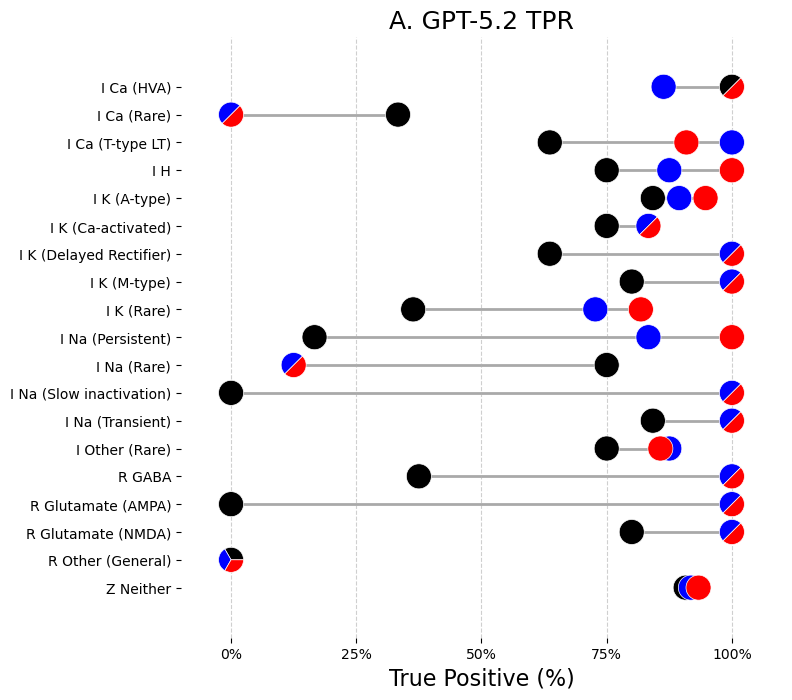

In [18]:


df = load_data_from_file(sens_fp)
    
# Check required columns
required_cols = ['true_subtype', 'sensitivity', 'model']
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}. Available columns: {list(df.columns)}")

print(f"Loaded {len(df)} rows of data")
print(f"Unique subtypes: {df['true_subtype'].nunique()}")
print(f"Unique models: {df['model'].unique()}")


# Transform TIDY data to plot configuration
plot_config = transform_tidy_data_to_plot_config(
    df,
    title="A. GPT-5.2 TPR",
    xlabel="True Positive (%)",
    xticks=[0, 0.25, 0.50, 0.75, 1],
    xticklabels=["0%", "25%", "50%", "75%", "100%"]
)

# Transform plot config to scatter data
points, line_segments, config = transform_plot_data(plot_config)

plot_custom_scatter(
    points,
    radius=0.025,
    title=config["title"],
    xlabel=config["xlabel"],
    ylabel="",  # Empty y-axis label
    xticks=config["xticks"],
    xticklabels=config["xticklabels"],
    yticks=config["yticks"],
    yticklabels=config["yticklabels"],
    line_segments=line_segments
)

Failed to load as Excel (Excel file format cannot be determined, you must specify an engine manually.), trying CSV...
Successfully loaded data from CSV file: gpt_mini_sensitivity.csv
Loaded 57 rows of data
Unique subtypes: 19
Unique models: ['XGB' 'GPT' 'GPT_H']


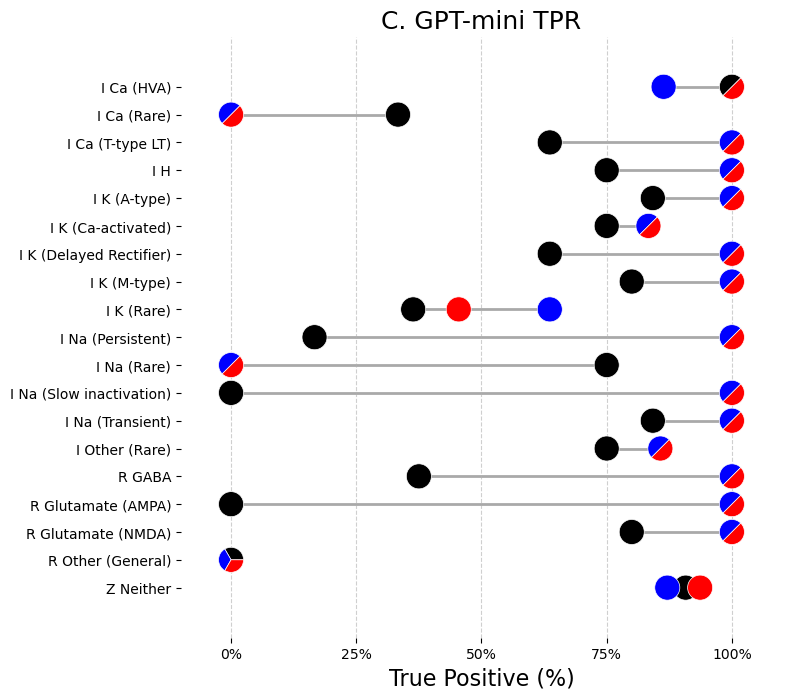

In [19]:


df = load_data_from_file(sens_mini_fp)
    
# Check required columns
required_cols = ['true_subtype', 'sensitivity', 'model']
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}. Available columns: {list(df.columns)}")

print(f"Loaded {len(df)} rows of data")
print(f"Unique subtypes: {df['true_subtype'].nunique()}")
print(f"Unique models: {df['model'].unique()}")


# Transform TIDY data to plot configuration
plot_config = transform_tidy_data_to_plot_config(
    df,
    title="C. GPT-mini TPR",
    xlabel="True Positive (%)",
    xticks=[0, 0.25, 0.50, 0.75, 1],
    xticklabels=["0%", "25%", "50%", "75%", "100%"]
)

# Transform plot config to scatter data
points, line_segments, config = transform_plot_data(plot_config)

plot_custom_scatter(
    points,
    radius=0.025,
    title=config["title"],
    xlabel=config["xlabel"],
    ylabel="",  # Empty y-axis label
    xticks=config["xticks"],
    xticklabels=config["xticklabels"],
    yticks=config["yticks"],
    yticklabels=config["yticklabels"],
    line_segments=line_segments
)

In [ ]:
fp_gpt52.columns

In [ ]:
df.columns

Failed to load as Excel (Excel file format cannot be determined, you must specify an engine manually.), trying CSV...
Successfully loaded data from CSV file: gpt_fp.csv
Loaded 57 rows of data
Unique subtypes: 19
Unique models: ['XGB' 'GPT' 'GPT_H']


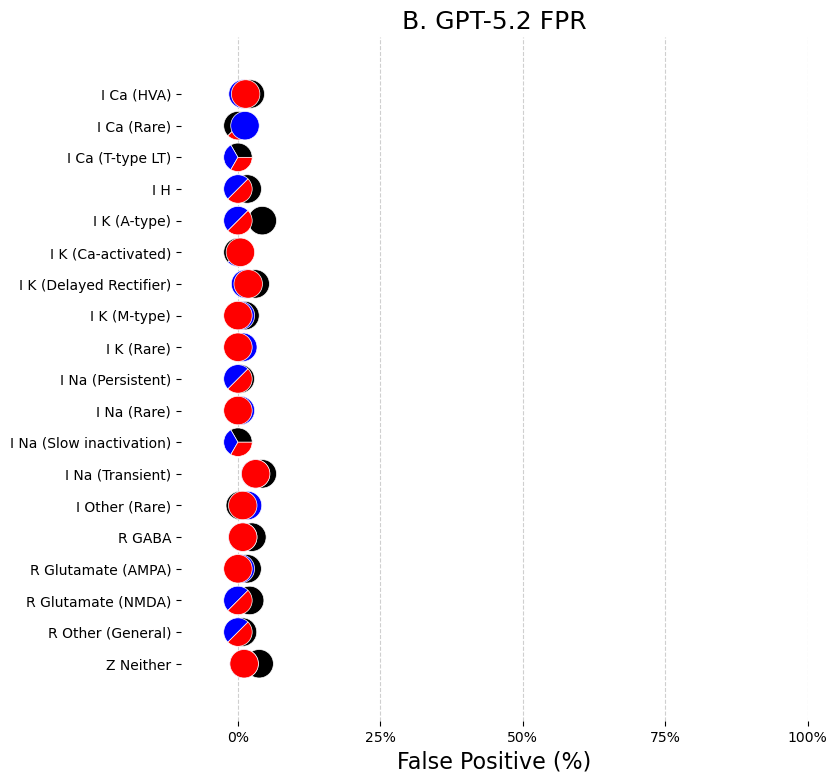

In [20]:
df = load_data_from_file(fp_fp)
    
# Check required columns
required_cols = ['true_subtype', 'sensitivity', 'model']
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}. Available columns: {list(df.columns)}")

print(f"Loaded {len(df)} rows of data")
print(f"Unique subtypes: {df['true_subtype'].nunique()}")
print(f"Unique models: {df['model'].unique()}")


# Transform TIDY data to plot configuration
plot_config = transform_tidy_data_to_plot_config(
    df,
    title="B. GPT-5.2 FPR",
    xlabel="False Positive (%)",
    xticks=[0, 0.25, 0.50, 0.75, 1],
    xticklabels=["0%", "25%", "50%", "75%", "100%"]
)

# Transform plot config to scatter data
points, line_segments, config = transform_plot_data(plot_config)

plot_custom_scatter(
    points,
    radius=0.025,
    title=config["title"],
    xlabel=config["xlabel"],
    ylabel="",  # Empty y-axis label
    xticks=config["xticks"],
    xticklabels=config["xticklabels"],
    yticks=config["yticks"],
    yticklabels=config["yticklabels"],
    line_segments=line_segments
)

Failed to load as Excel (Excel file format cannot be determined, you must specify an engine manually.), trying CSV...
Successfully loaded data from CSV file: gpt_mini_fp.csv
Loaded 57 rows of data
Unique subtypes: 19
Unique models: ['XGB' 'GPT' 'GPT_H']


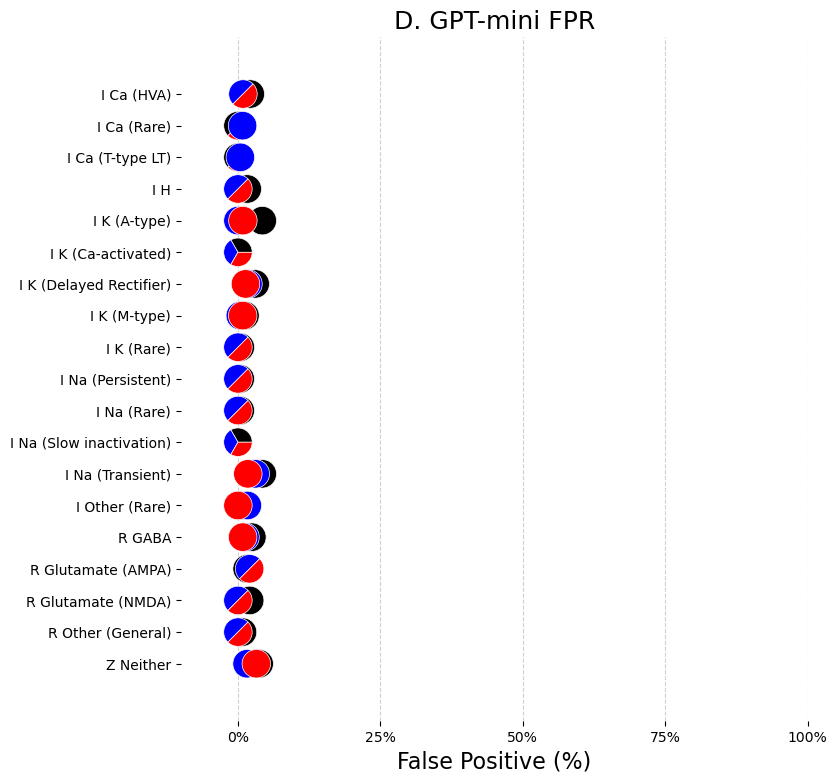

In [21]:
df = load_data_from_file(fp_mini_fp)
    
# Check required columns
required_cols = ['true_subtype', 'sensitivity', 'model']
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}. Available columns: {list(df.columns)}")

print(f"Loaded {len(df)} rows of data")
print(f"Unique subtypes: {df['true_subtype'].nunique()}")
print(f"Unique models: {df['model'].unique()}")


# Transform TIDY data to plot configuration
plot_config = transform_tidy_data_to_plot_config(
    df,
    title="D. GPT-mini FPR",
    xlabel="False Positive (%)",
    xticks=[0, 0.25, 0.50, 0.75, 1],
    xticklabels=["0%", "25%", "50%", "75%", "100%"]
)

# Transform plot config to scatter data
points, line_segments, config = transform_plot_data(plot_config)

plot_custom_scatter(
    points,
    radius=0.025,
    title=config["title"],
    xlabel=config["xlabel"],
    ylabel="",  # Empty y-axis label
    xticks=config["xticks"],
    xticklabels=config["xticklabels"],
    yticks=config["yticks"],
    yticklabels=config["yticklabels"],
    line_segments=line_segments
)

Failed to load as Excel (Excel file format cannot be determined, you must specify an engine manually.), trying CSV...
Successfully loaded data from CSV file: gpt_ppv.csv
Loaded 57 rows of data
Unique subtypes: 19
Unique models: ['XGB' 'GPT' 'GPT_H']


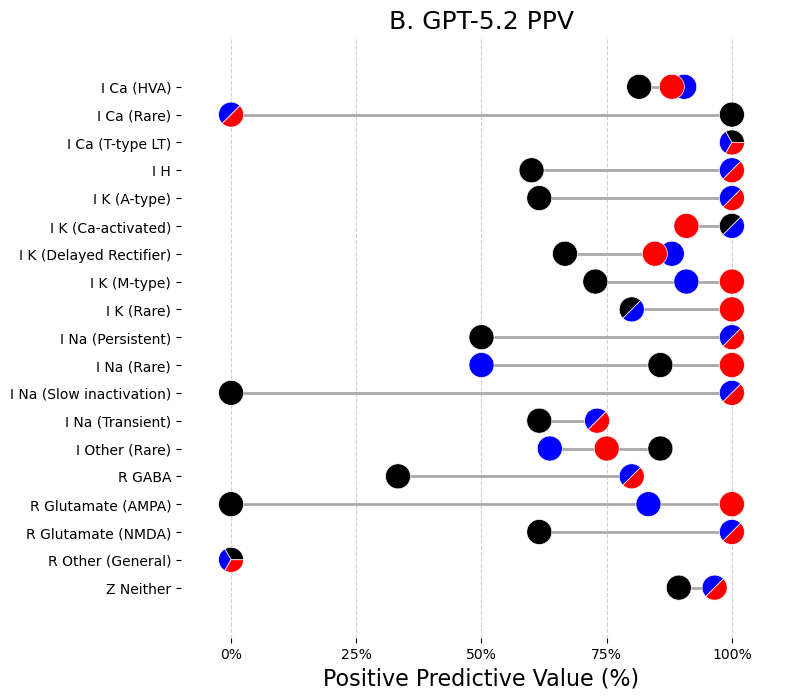

In [ ]:
df = load_data_from_file(ppv_fp)
    
# Check required columns
required_cols = ['true_subtype', 'sensitivity', 'model']
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}. Available columns: {list(df.columns)}")

print(f"Loaded {len(df)} rows of data")
print(f"Unique subtypes: {df['true_subtype'].nunique()}")
print(f"Unique models: {df['model'].unique()}")


# Transform TIDY data to plot configuration
plot_config = transform_tidy_data_to_plot_config(
    df,
    title="B. GPT-5.2 PPV",
    xlabel="Positive Predictive Value (%)",
    xticks=[0, 0.25, 0.50, 0.75, 1],
    xticklabels=["0%", "25%", "50%", "75%", "100%"]
)

# Transform plot config to scatter data
points, line_segments, config = transform_plot_data(plot_config)

plot_custom_scatter(
    points,
    radius=0.025,
    title=config["title"],
    xlabel=config["xlabel"],
    ylabel="",  # Empty y-axis label
    xticks=config["xticks"],
    xticklabels=config["xticklabels"],
    yticks=config["yticks"],
    yticklabels=config["yticklabels"],
    line_segments=line_segments
)

Failed to load as Excel (Excel file format cannot be determined, you must specify an engine manually.), trying CSV...
Successfully loaded data from CSV file: gpt_mini_ppv.csv
Loaded 57 rows of data
Unique subtypes: 19
Unique models: ['XGB' 'GPT' 'GPT_H']


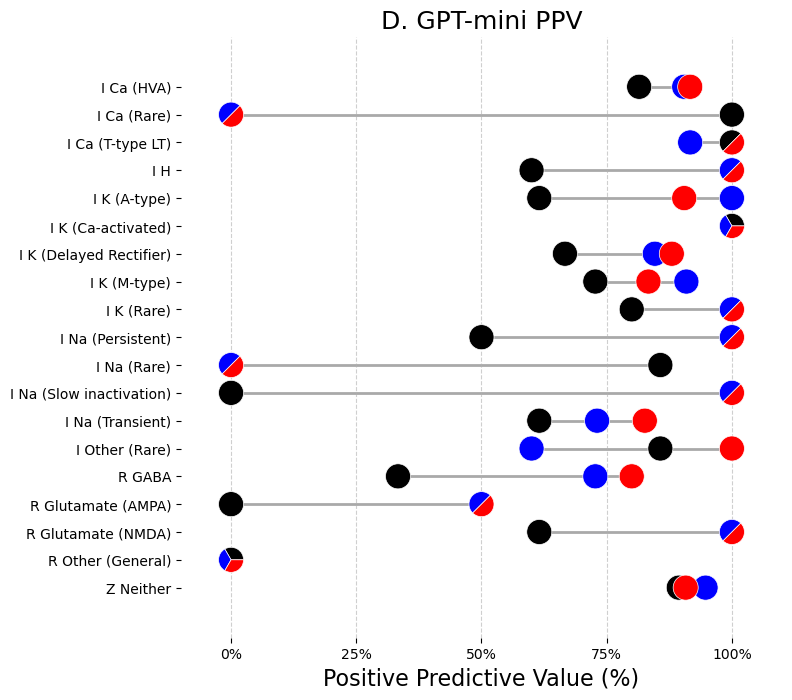

In [34]:

df = load_data_from_file(ppv_mini_fp)
    
# Check required columns
required_cols = ['true_subtype', 'sensitivity', 'model']
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}. Available columns: {list(df.columns)}")

print(f"Loaded {len(df)} rows of data")
print(f"Unique subtypes: {df['true_subtype'].nunique()}")
print(f"Unique models: {df['model'].unique()}")


# Transform TIDY data to plot configuration
plot_config = transform_tidy_data_to_plot_config(
    df,
    title="D. GPT-mini PPV",
    xlabel="Positive Predictive Value (%)",
    xticks=[0, 0.25, 0.50, 0.75, 1],
    xticklabels=["0%", "25%", "50%", "75%", "100%"]
)

# Transform plot config to scatter data
points, line_segments, config = transform_plot_data(plot_config)

plot_custom_scatter(
    points,
    radius=0.025,
    title=config["title"],
    xlabel=config["xlabel"],
    ylabel="",  # Empty y-axis label
    xticks=config["xticks"],
    xticklabels=config["xticklabels"],
    yticks=config["yticks"],
    yticklabels=config["yticklabels"],
    line_segments=line_segments
)